# Olympic Data Analysis & Streamlit App

Dieses Projekt besteht aus zwei Teilen:

1. **Jupyter Notebook** mit verschiedenen SQL Querys zu den Olympia Daten
2. **Streamlit-App** mit zwei interaktiven Funktionen:

**Olympic Sports Recommender**

Die App empfiehlt passende olympische Sportarten auf Basis eines eingegebenen Körperprofils.

Dafür werden folgende Merkmale berücksichtigt: 

Größe,
Gewicht,
Alter,
Geschlecht

Die Empfehlung basiert auf einem Similarity Score, der die Ähnlichkeit zwischen dem eingegebenen Profil und dem durchschnittlichen Profil historischer Medaillengewinner je Sportart misst.

**Alle Medaillengewinner Olympia 1904 - 2016**

Dieser Bereich ermöglicht das Filtern von Medaillengewinnern nach:

Land,
Jahr,
Sportart,
Disziplin,
Team oder Einzelwertung,
Medaillen


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

## Datenbankverbindung

In diesem Abschnitt wird die Verbindung zur PostgreSQL-Datenbank hergestellt. Die Daten wurden zuvor normalisiert, importiert und validiert und können nun für die Analyse genutzt werden.

In [2]:
DB_USER = "postgres"
DB_PASSWORD = "postgres"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "olympics"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

In [4]:
with engine.connect() as conn:
    print("Verbindung erfolgreich")

Verbindung erfolgreich


## 1. Anzahl der Medaillen pro Land

Diese Analyse zeigt die erfolgreichsten Länder bei den Olympischen Spielen und differenziert deren Medaillen nach Gold, Silber und Bronze.

Die Ergebnisse zeigen nicht nur, welche Länder viele Medaillen gewonnen haben, sondern auch, wie sich diese auf die einzelnen Medaillentypen verteilen. Dadurch lassen sich sportliche Erfolgsstrukturen der Länder genauer vergleichen.

In [ ]:
query_country_medals = """
SELECT
    c.country,
    SUM(CASE WHEN r.medal = 'Gold' THEN 1 ELSE 0 END) AS gold_medals,
    SUM(CASE WHEN r.medal = 'Silver' THEN 1 ELSE 0 END) AS silver_medals,
    SUM(CASE WHEN r.medal = 'Bronze' THEN 1 ELSE 0 END) AS bronze_medals,
    COUNT(*) AS total_medals
FROM result r
JOIN country c ON r.noc = c.noc
WHERE r.medal IS NOT NULL
GROUP BY c.country
ORDER BY total_medals DESC
LIMIT 10;
"""

df_country_medals = pd.read_sql(query_country_medals, engine)
df_country_medals

,country,gold_medals,silver_medals,bronze_medals,total_medals
0,USA,2419,1304,1172,4895
1,Russia,1220,974,994,3188
2,Germany,1022,952,1045,3019
3,UK,565,670,594,1829
4,Italy,494,464,427,1385
5,Australia,357,456,508,1321
6,France,388,454,475,1317
7,Hungary,424,320,355,1099
8,Sweden,349,391,343,1083
9,China,335,319,259,913


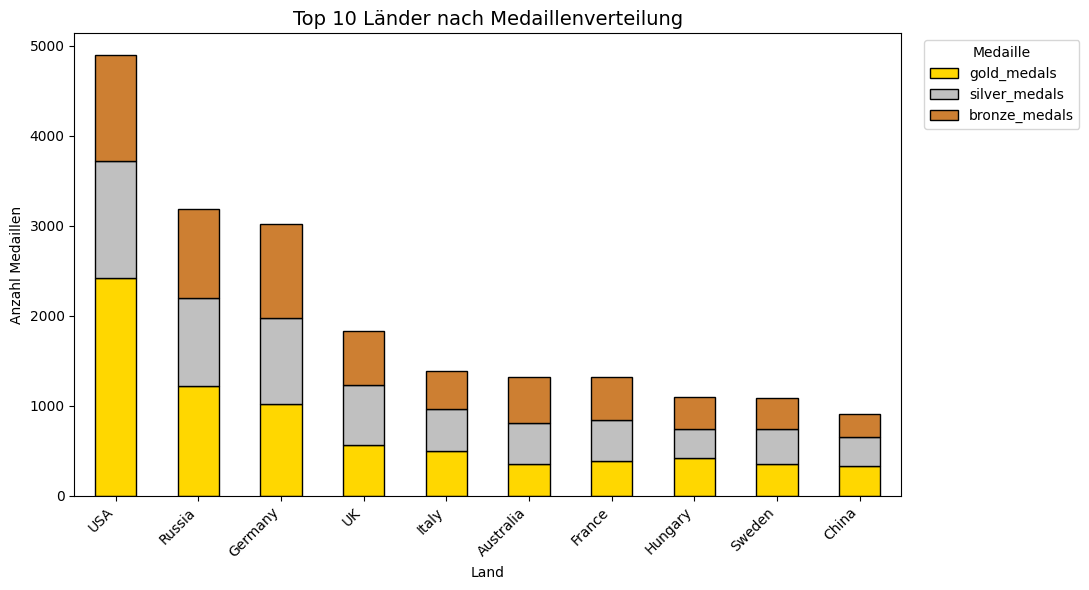

In [50]:
# Daten vorbereiten
df_country_medals_plot = (
    df_country_medals
    .sort_values("total_medals", ascending=False)
    .set_index("country")[["gold_medals","silver_medals","bronze_medals"]]
)

# Plot erstellen
ax = df_country_medals_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(11,6),
    color=["#FFD700","#C0C0C0","#CD7F32"],  # Gold, Silber, Bronze
    edgecolor="black"
)

# Titel und Labels
plt.title("Top 10 Länder nach Medaillenverteilung", fontsize=14)
plt.xlabel("Land")
plt.ylabel("Anzahl Medaillen")

# X-Achsen Labels lesbarer
plt.xticks(rotation=45, ha="right")

# Legende verbessern
plt.legend(title="Medaille", bbox_to_anchor=(1.02,1), loc="upper left")

# Layout sauber halten
plt.tight_layout()

plt.show()

## 2. Anzahl Medaillen nach Sportart

Diese Analyse untersucht, in welchen Sportarten die meisten Medaillen vergeben wurden.

Die Ergebnisse zeigen, welche Sportarten historisch besonders stark vertreten sind. Dadurch lassen sich Unterschiede in der Bedeutung und Größe einzelner olympischer Disziplinen erkennen.

In [8]:
query_sports = """
SELECT 
    s.sport_name,
    COUNT(*) AS medals
FROM result r
JOIN event e ON r.event_id = e.event_id
JOIN sport s ON e.sport_id = s.sport_id
WHERE r.medal IS NOT NULL
GROUP BY s.sport_name
ORDER BY medals DESC
LIMIT 15;
"""

df_sports = pd.read_sql(query_sports, engine)
df_sports

,sport_name,medals
0,Athletics,3791
1,Swimming,2985
2,Rowing,2770
3,Gymnastics,2160
4,Fencing,1672
5,Hockey,1528
6,Football,1502
7,Wrestling,1281
8,Cycling,1217
9,Canoeing,1165


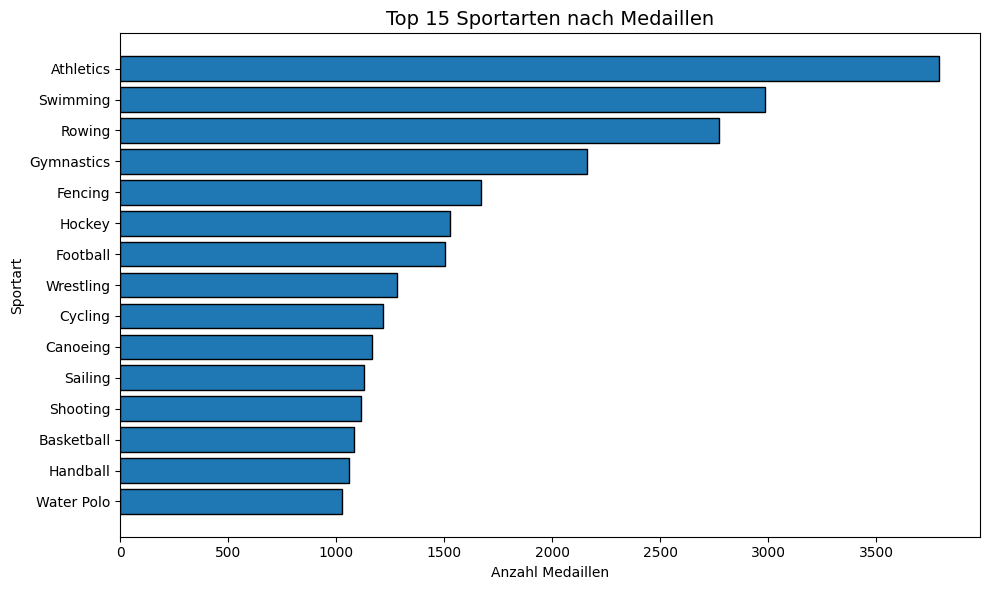

In [55]:
df_sports_plot = df_sports.sort_values("medals", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_sports_plot["sport_name"], df_sports_plot["medals"], edgecolor="black")

plt.title("Top 15 Sportarten nach Medaillen", fontsize=14)
plt.xlabel("Anzahl Medaillen")
plt.ylabel("Sportart")

plt.tight_layout()
plt.show()

## 3. Entwicklung der Gesamtanzahl der Medaillen über die Jahre

Diese Analyse zeigt, wie sich die Anzahl der vergebenen Medaillen über die Zeit entwickelt hat.

Die Ergebnisse helfen dabei, Trends in der Entwicklung der Olympischen Spiele sichtbar zu machen. Veränderungen können auf neue Sportarten, zusätzliche Wettbewerbe oder strukturelle Anpassungen im olympischen Programm hinweisen.

In [12]:
query_years = """
SELECT 
    r.year,
    COUNT(*) AS medals
FROM result r
WHERE r.medal IS NOT NULL
GROUP BY r.year
ORDER BY r.year;
"""
df_years = pd.read_sql(query_years, engine)
df_years

,year,medals
0,1904,486
1,1908,831
2,1912,941
3,1920,1308
4,1924,832
5,1928,734
6,1932,647
7,1936,917
8,1948,851
9,1952,897


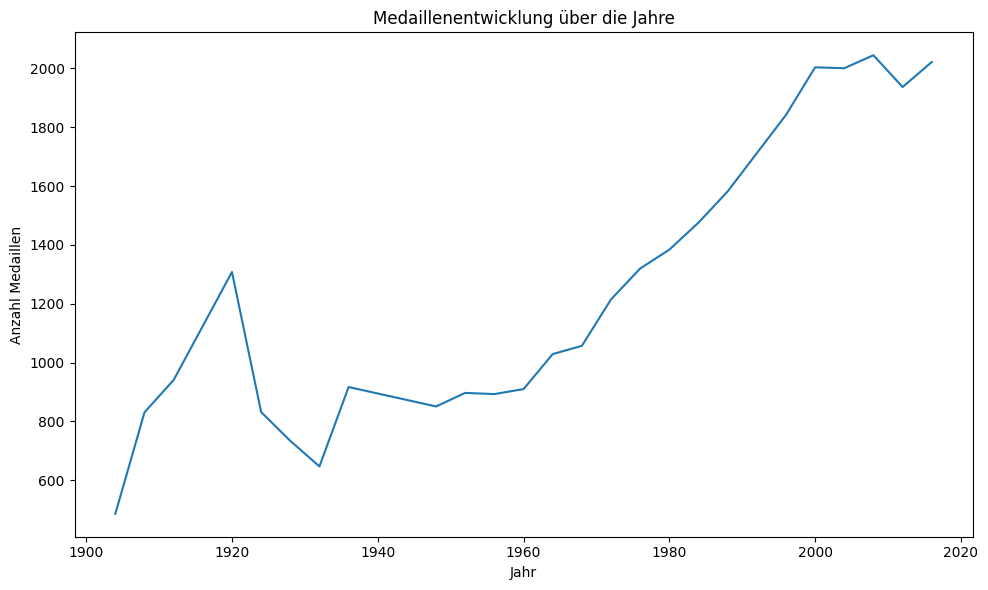

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(df_years["year"], df_years["medals"])
plt.title("Medaillenentwicklung über die Jahre")
plt.xlabel("Jahr")
plt.ylabel("Anzahl Medaillen")
plt.tight_layout()
plt.show()

## 4. Top-Sportarten eines ausgewählten Landes

Diese Analyse zeigt, in welchen Sportarten ein bestimmtes Land besonders erfolgreich ist. Dafür werden Medaillen nach Land und Sportart aggregiert.

Die Ergebnisse zeigen nationale Stärken in bestimmten Disziplinen. Solche Muster sind für Medien interessant, da sie sportliche Spezialisierungen einzelner Länder sichtbar machen.

In [20]:
country_name = "Germany"

query_country_sports = f"""
SELECT 
    s.sport_name,
    COUNT(*) AS medals
FROM result r
JOIN country c ON r.noc = c.noc
JOIN event e ON r.event_id = e.event_id
JOIN sport s ON e.sport_id = s.sport_id
WHERE r.medal IS NOT NULL
AND c.country = '{country_name}'
GROUP BY s.sport_name
ORDER BY medals DESC
LIMIT 10;
"""

df_country_sports = pd.read_sql(query_country_sports, engine)
df_country_sports


,sport_name,medals
0,Rowing,455
1,Athletics,362
2,Swimming,358
3,Hockey,248
4,Canoeing,229
5,Equestrianism,205
6,Football,173
7,Cycling,149
8,Gymnastics,136
9,Fencing,115


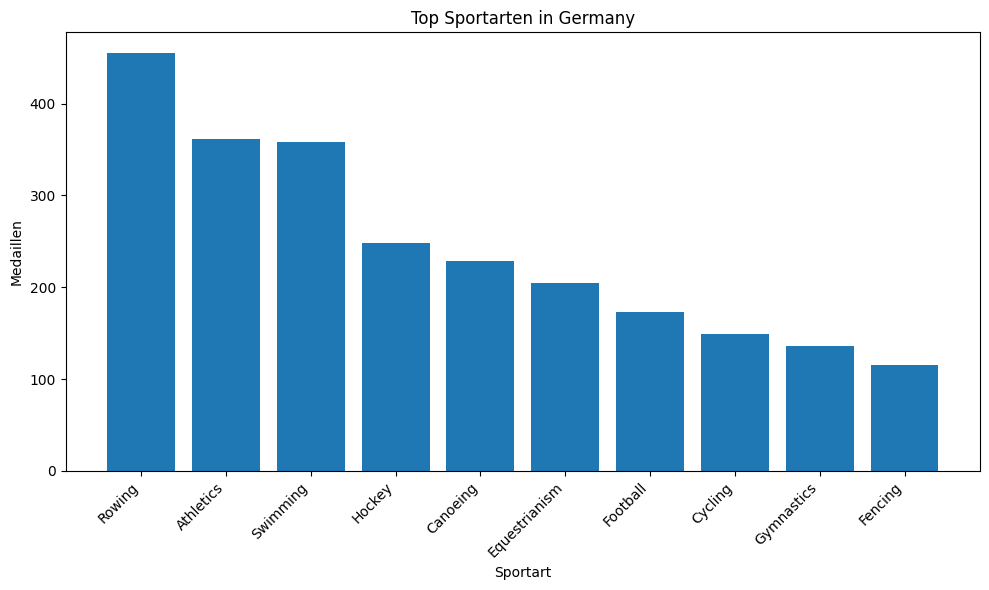

In [21]:
plt.figure(figsize=(10,6))

plt.bar(df_country_sports["sport_name"], df_country_sports["medals"])

plt.xticks(rotation=45, ha="right")
plt.title(f"Top Sportarten in {country_name}")
plt.xlabel("Sportart")
plt.ylabel("Medaillen")

plt.tight_layout()
plt.show()

## 5. Körperprofile erfolgreicher Athleten pro Sportart

Diese Analyse untersucht die durchschnittlichen körperlichen Merkmale erfolgreicher Athleten in verschiedenen Sportarten.

Die Ergebnisse zeigen, dass bestimmte Sportarten mit typischen Körperprofilen verbunden sind. Diese Erkenntnisse sind besonders für Personal Trainer interessant, da sie Hinweise auf sportartspezifische Voraussetzungen geben.

In [59]:
query_body_profiles = """
SELECT 
    s.sport_name,
    ROUND(AVG(a.height)::numeric, 2) AS avg_height,
    ROUND(AVG(a.weight)::numeric, 2) AS avg_weight,
    ROUND(AVG(r.age)::numeric, 2) AS avg_age,
    COUNT(*) AS medal_winners
FROM result r
JOIN athlete a ON r.athlete_id = a.athlete_id
JOIN event e ON r.event_id = e.event_id
JOIN sport s ON e.sport_id = s.sport_id
WHERE r.medal IS NOT NULL
  AND a.height IS NOT NULL
  AND a.weight IS NOT NULL
GROUP BY s.sport_name
HAVING COUNT(*) >= 20
ORDER BY medal_winners DESC;
"""

df_body_profiles = pd.read_sql(query_body_profiles, engine)

# Umrechnung der Einheiten
df_body_profiles["avg_height"] = (df_body_profiles["avg_height"] / 10).round(2)
df_body_profiles["avg_weight"] = (df_body_profiles["avg_weight"] / 10).round(2)

df_body_profiles.head(10)

,sport_name,avg_height,avg_weight,avg_age,medal_winners
0,Athletics,177.56,71.45,25.08,3566
1,Swimming,181.12,73.25,21.03,2477
2,Rowing,184.62,80.86,25.87,2105
3,Hockey,173.66,69.19,25.75,1168
4,Gymnastics,161.26,55.03,21.80,1157
5,Fencing,178.03,72.12,27.09,1105
6,Football,175.48,70.74,24.22,1084
7,Canoeing,179.52,78.03,25.87,1041
8,Basketball,192.15,86.69,25.30,1000
9,Wrestling,172.72,76.55,25.80,969


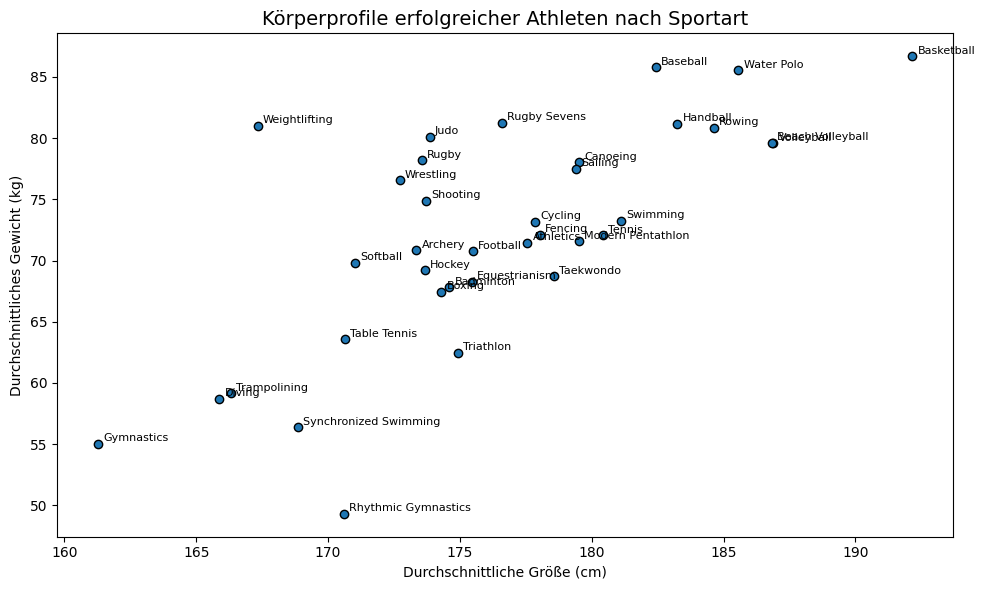

In [58]:
df_body_profiles_plot = df_body_profiles.copy()

plt.figure(figsize=(10, 6))

plt.scatter(
    df_body_profiles_plot["avg_height"],
    df_body_profiles_plot["avg_weight"],
    edgecolors="black"
)

for _, row in df_body_profiles_plot.iterrows():
    plt.text(
        row["avg_height"] + 0.2,
        row["avg_weight"] + 0.2,
        row["sport_name"],
        fontsize=8
    )

plt.title("Körperprofile erfolgreicher Athleten nach Sportart", fontsize=14)
plt.xlabel("Durchschnittliche Größe (cm)")
plt.ylabel("Durchschnittliches Gewicht (kg)")

plt.tight_layout()
plt.show()

## 6. Erfolgreiche Sportarten für große Athleten

Diese Analyse untersucht, in welchen Sportarten der Anteil großer erfolgreicher Athleten besonders hoch ist. Dafür wird der prozentuale Anteil von Medaillengewinnern mit einer Körpergröße von mindestens 190 cm pro Sportart berechnet.

Die Ergebnisse zeigen, in welchen Disziplinen große Athleten überdurchschnittlich häufig erfolgreich sind. Diese Analyse ist aussagekräftiger als absolute Häufigkeiten und eignet sich besonders gut als Grundlage für ein späteres Empfehlungssystem.

In [67]:
query_tall_share = """
SELECT 
    s.sport_name,
    COUNT(DISTINCT CASE WHEN a.height >= 1900 THEN r.result_id END) AS tall_medals,
    COUNT(DISTINCT r.result_id) AS total_medals,
    ROUND(
        100.0 * COUNT(DISTINCT CASE WHEN a.height >= 1900 THEN r.result_id END)
        / COUNT(DISTINCT r.result_id),
        2
    ) AS tall_share_pct
FROM result r
JOIN athlete a ON r.athlete_id = a.athlete_id
JOIN event e ON r.event_id = e.event_id
JOIN sport s ON e.sport_id = s.sport_id
WHERE r.medal IS NOT NULL
  AND a.height IS NOT NULL
GROUP BY s.sport_name
HAVING COUNT(DISTINCT r.result_id) >= 20
ORDER BY tall_share_pct DESC
LIMIT 10;
"""

df_tall_share = pd.read_sql(query_tall_share, engine)
df_tall_share

,sport_name,tall_medals,total_medals,tall_share_pct
0,Basketball,620,1024,60.55
1,Beach Volleyball,32,68,47.06
2,Volleyball,426,959,44.42
3,Rowing,786,2165,36.30
4,Water Polo,286,791,36.16
5,Handball,284,950,29.89
6,Swimming,533,2551,20.89
7,Tennis,33,179,18.44
8,Taekwondo,26,144,18.06
9,Baseball,54,333,16.22


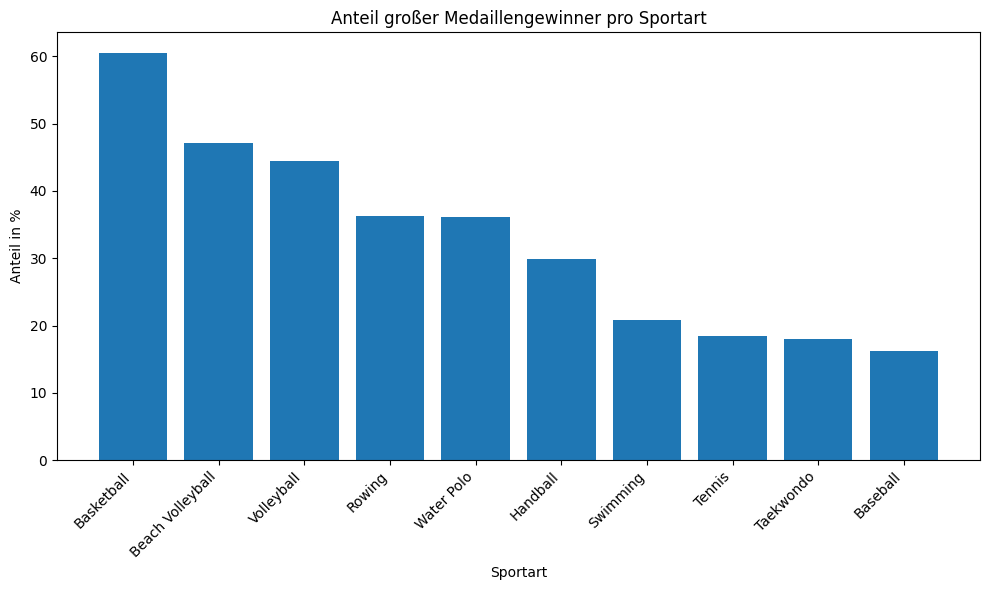

In [29]:
plt.figure(figsize=(10,6))
plt.bar(df_tall_share["sport_name"], df_tall_share["tall_share_pct"])
plt.xticks(rotation=45, ha="right")
plt.title("Anteil großer Medaillengewinner pro Sportart")
plt.xlabel("Sportart")
plt.ylabel("Anteil in %")
plt.tight_layout()
plt.show()

## 7. Sportartenempfehlung auf Basis ähnlicher Erfolgsprofile

Diese Analyse vergleicht ein eingegebenes Körperprofil mit den durchschnittlichen Profilen erfolgreicher Athleten je Sportart. Dafür werden Größe, Gewicht, Alter und Geschlecht der Medaillengewinner berücksichtigt.

Die Ergebnisse zeigen, welche Sportarten dem eingegebenen Profil am ähnlichsten sind. Diese Analyse ist besonders relevant für Personal Trainer, da sie eine erste datenbasierte Grundlage für die Empfehlung geeigneter Sportarten bietet.

In [60]:
query_recommendation_profiles = """
SELECT
    s.sport_name,
    a.sex,
    ROUND(AVG(a.height)::numeric, 2) AS avg_height,
    ROUND(AVG(a.weight)::numeric, 2) AS avg_weight,
    ROUND(AVG(r.age)::numeric, 2) AS avg_age,
    COUNT(*) AS medal_winners
FROM result r
JOIN athlete a ON r.athlete_id = a.athlete_id
JOIN event e ON r.event_id = e.event_id
JOIN sport s ON e.sport_id = s.sport_id
WHERE r.medal IS NOT NULL
  AND a.height IS NOT NULL
  AND a.weight IS NOT NULL
  AND r.age IS NOT NULL
GROUP BY s.sport_name, a.sex
HAVING COUNT(*) >= 20
ORDER BY medal_winners DESC;
"""

df_recommendation_profiles = pd.read_sql(query_recommendation_profiles, engine)

# Umrechnung in cm und kg
df_recommendation_profiles["avg_height"] = (df_recommendation_profiles["avg_height"] / 10).round(2)
df_recommendation_profiles["avg_weight"] = (df_recommendation_profiles["avg_weight"] / 10).round(2)

df_recommendation_profiles.head()

,sport_name,sex,avg_height,avg_weight,avg_age,medal_winners
0,Athletics,M,181.27,76.34,25.01,2327
1,Rowing,M,188.17,85.46,25.92,1397
2,Swimming,M,187.21,81.41,21.98,1310
3,Athletics,F,170.60,62.28,25.20,1239
4,Swimming,F,174.28,64.08,19.97,1167


In [63]:
user_height = 185
user_weight = 80
user_age = 25
user_sex = "M"

df_user_match = df_recommendation_profiles[
    df_recommendation_profiles["sex"] == user_sex
].copy()

df_user_match["distance"] = (
    (df_user_match["avg_height"] - user_height) ** 2 +
    (df_user_match["avg_weight"] - user_weight) ** 2 +
    (df_user_match["avg_age"] - user_age) ** 2
) ** 0.5

df_user_match = df_user_match.sort_values("distance").head(10)

df_user_match[["sport_name", "sex", "avg_height", "avg_weight", "avg_age", "distance"]]

,sport_name,sex,avg_height,avg_weight,avg_age,distance
47,Tennis,M,185.86,80.12,26.47,1.707308
8,Canoeing,M,182.58,82.29,25.65,3.394554
2,Swimming,M,187.21,81.41,21.98,3.999075
54,Taekwondo,M,185.33,75.97,24.03,4.158209
0,Athletics,M,181.27,76.34,25.01,5.225763
7,Fencing,M,181.46,76.77,27.54,5.423661
44,Archery,M,179.21,78.82,25.27,5.915184
12,Cycling,M,180.14,75.94,24.67,6.341301
1,Rowing,M,188.17,85.46,25.92,6.380196
28,Baseball,M,182.43,85.78,26.26,6.449876


In [64]:
top_3_sports = df_user_match["sport_name"].head(3).tolist()
print("Empfohlene Sportarten:", top_3_sports)

Empfohlene Sportarten: ['Tennis', 'Canoeing', 'Swimming']


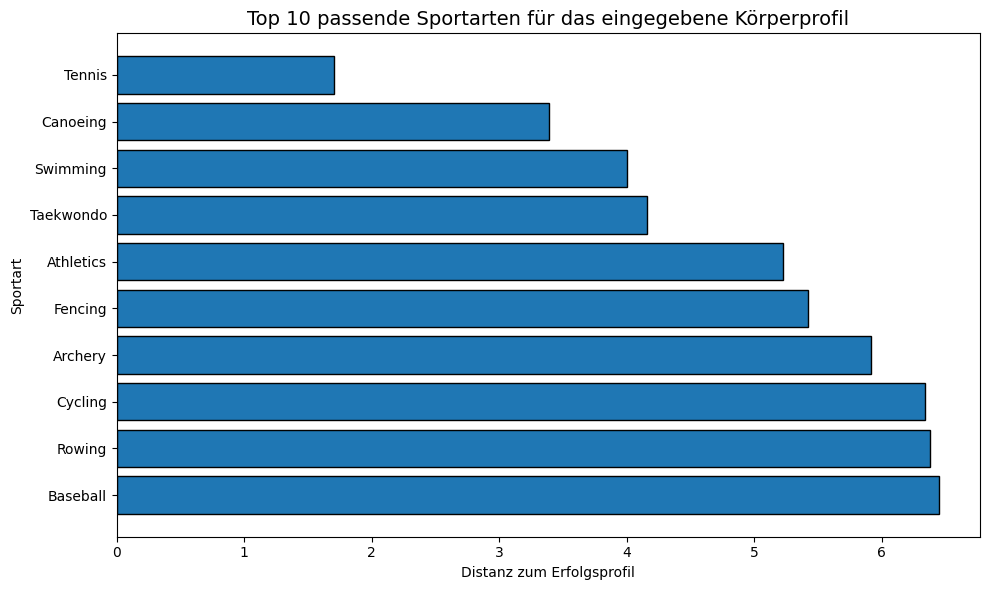

In [65]:
df_plot = df_user_match.sort_values("distance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(df_plot["sport_name"], df_plot["distance"], edgecolor="black")

plt.title("Top 10 passende Sportarten für das eingegebene Körperprofil", fontsize=14)
plt.xlabel("Distanz zum Erfolgsprofil")
plt.ylabel("Sportart")

plt.tight_layout()
plt.show()